# College of Computing and Informatics, Drexel University
## INFO 371: Data Mining Applications

---

## Final Project Report

## Project Title: Classifying Human vs AI Generated Text

## Student(s): Daniel Ting, Phone Kyaw, Anna Zhu

#### Date: 3/14/2026
---

# Requirements:
1. **Formatting and Structure**:
The report must follow a clear, logical structure (use headings, subheadings, markdown cells, and code cells for organization).
2. **Code and Results**:
Include all code in code cells. Ensure the code is clean, readable, and uses proper commenting where necessary.
3. **Explanations**: Use markdown cells to clearly explain each step of the analysis, modeling, and evaluation process. Provide context for the code being executed. Interpret the results (e.g., what do the visualizations show? What models do you choose? How do you evaluate the results? What insights can be drawn?).
4. **Reproducibility**:
Provide all code and commands necessary for reproducing your analysis. Ensure all data imports, transformations, and analyses run correctly in sequence.

# Marking Scheme:
- **Organization and Formatting (10 points)**: Is the notebook well-structured and visually clean?
- **Reproducibility (10 points)**: Can the entire analysis be reproduced seamlessly?
- **Code Quality (20 points)**: Is the code clear, concise, and well-documented?
- **Explanations and Insights (20 points)**: Are steps and results well-explained and insightful?
- **Data Visualization and Presentation (20 points)**: Are plots and tables effective and well-labeled?
- **Technical Content (20 points)**:
 * Is the problem well defined and described thoroughly?
 * Is the size and complexity of the data set used in this project comparable to that of the example data sets used in the lectures and assignments?
 * Did the report describe the characteristics of the data?
 * Did the report describe the goals of the data miming?
 * Did the projet use feature engineering and feature selection methods?
 * Did the project build, compare, and evaluate multiple models?
 * Did the report discuss the results and findings?
 * Did the report include all related references?
- **Only those projects that exceed the sophistication of the data mining examples in the lectures and assignments can be marked as the highest level of grade**.
- **Overall, what is the rating of this project?**

# YOUR REPORT GOES HERE

# 1. Introduction
---
- Introduce the project and describe the objectives.
- State the main questions or problems you aim to address with your project.
- Provide a summary of the entire project, including the data, analytics methods, machine learning techniques, and key findings.

This project's main objective is to create create a text classification model that can detect whether a string of text was generated by a human or an AI. This includes:
* Loading the dataset and performing exploratory data analysis to prepare and understand it
* Running classical machine learning models to find the best combination of vectorizers, classifiers, and features
* Finetuning a BERT Transformer model to improve the results of the classification task

The main problem we aim to address is that AI generated text creates an epistemic pollution problem. If we can not tell what is real, trust breaks down. In academia, this is a major problem since credentials and grades lose meaning if students can easily use AI to complete assignments and essays. In journalism, AI allows for the rapid creation of fake news and zero cost. Many of these industries would benefit greatly if given the ability to distinguish human vs AI generated text. Our project seeks to solve this problem by creating a machine learning model that can determine text as either human or AI generated.

This project includes:
* Loading a Human vs. LLM Text Corpus containing almost 800k rows and 5 columns: text, prompt id, text length, word count, and source (label)
* Exploring the data by checking for missing values, finding the number of different sources, altering labels for binary classification, and finding the percentage of human vs AI text samples
* Making histograms and box plots comparing the distribution of text length and word count between human vs ai generated text as well as comparing overall counts
* Splitting the data into shuffled training and testing sets in a 80-20 split while keeping them stratified
* Feature engineering by adding vocab richness and stop word ratio
* Running randomized search cross validation on vectorizers like Binary BOW, Count BOW, and tfidf with classifiers like Decision Tree, Random Forest, and Multinomial Naive Bayes.
* Comparing f1 score prediction performance between multiple vectorizer + classifier combinations on different datasets
* Running it on a Word2Vec + Multi Layer Perceptron and evaluating performance
* Finetuning a BERT Transformer model with a linear classifier as the head and evaluating it

Key findings:
* Human generated text tends to be much longer than AI, at least for this dataset
* On traditional ML techniques, a BOW Counts vectrizer + Random Forest Classifier had the best results at 87% F1 Score
* Adding additional features to the text dataset had a slight performance improvement (+0.01)

# 2. Data Description
---
- Data Source: Describe the origin of your dataset. Provide a link if applicable.
- Data Loading: Present the code and methods for acquiring the data. Load the data into appropriate format for analysis.
- Dataset Analysis: Analyze the key attributes and features of your dataset (e.g., number of rows, columns, types of data).
- Data Cleaning: Clean and preprocess the data, including handling missing values or duplicates.

# 3. Exploratory Data Analysis
---

The analysis should be guided by the problem defined earlier. Show your code and explain the process and results.

- Exploratory Analysis:
 * Use visualizations and summary statistics to understand the data.
 * Include plots such as histograms, scatter plots, box plots, correlation matrices, etc.
 * Explain key trends and relationships observed in the data.
- Insights: Provide interpretations of patterns, distributions, and anomalies in the data.
- Feature Engineering and Selection:
 * Extract or construct new features relevant to the problem.
 * Highlight the features that will be used in your model and justify their selection (e.g., based on correlation or domain knowledge).


# 4. Model Building and Evaluation
---
- Model Selection: Describe the machine learning or data mining techniques used (e.g., regression, classification, clustering, association rules, etc.) and justify your choice.

- Model Implementation: Present and explain the code for implementing the chosen models.
 * Describe the architecture of your solution (e.g., train-test split, cross-validation, data pipelines).
 * Discuss any hyperparameter tuning strategies (e.g., grid search) and the range of parameters explored.

- Model Evaluation:
 * Define the metrics used to evaluate the model's performance.
 * Compare the results of different models and approaches
 * Use tables or plots (e.g., confusion matrix, precision-recall curves, ROC curves, or feature importance plots) to illustrate performance.
 * Report training vs. testing performance to highlight potential overfitting or underfitting issues.
- Model Interpretation:
 * Explain the results of the model in the context of your original problem or question.
 * Identify which features contributed most to the model's predictions and provide explanations.


## Text Classification Using Deep Learning

In this notebook, we will explore RNNs and BERT to test out the performance of the algorithms against classifying whether a sequence is generated by humans or AI. The reason we choose these models are that they perform well with seqeunces or time-series data

In [ ]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.7 MB/s eta 0:00:00:00:0100:01


In [ ]:
# For BERT
!pip install -q -U keras keras-hub tensorflow

In [ ]:
import numpy as np
import pandas as pd
import os
import pickle

import spacy
import gensim.downloader as api

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from sklearn.metrics import f1_score
import keras
import keras_hub
import tensorflow as tf

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path = "/content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject"
# folder_path = "data"
print(os.listdir(folder_path))

['test.txt', 'train.txt', 'model_brnn_v1.weights.h5', 'tokenized_texts_train_len-10000_seed-0']


### Training with Smaller Dataset and Observing

Since our data is large, we will first sample only 1000 instances from the traning data to test with different RNN model architecture and hyperparameters, and see whether it performs well or not.

In [ ]:
train = pd.read_csv(os.path.join(folder_path, "train.txt"))

In [ ]:
print(train.info())
print(f"Memory Usage In MB: {train.memory_usage().sum() / 1e6}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631137 entries, 0 to 631136
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   text          631137 non-null  object
 1   text_length   631137 non-null  int64 
 2   word_count    631137 non-null  int64 
 3   ai_generated  631137 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 19.3+ MB
None
Memory Usage In MB: 20.196516


In [ ]:
train.head(5)

,text,text_length,word_count,ai_generated
0,Analysis of Blood System’s Sides Essay\n\nThe ...,2363,344,0
1,"In May 2013, ABC launched ""WATCH ABC,"" a revam...",2528,400,1
2,Wireless Sensor Networks (WSNs) with their dyn...,7444,887,1
3,Ethereal qualities and sexuality in art: Aphro...,3730,604,0
4,"In the annals of human exploration, the final ...",4207,656,1


In [ ]:
df = train[["text", "ai_generated"]].copy()
df = df.dropna(subset=["text", "ai_generated"])

print(df.shape)
df.head()

(631137, 2)


,text,ai_generated
0,Analysis of Blood System’s Sides Essay\n\nThe ...,0
1,"In May 2013, ABC launched ""WATCH ABC,"" a revam...",1
2,Wireless Sensor Networks (WSNs) with their dyn...,1
3,Ethereal qualities and sexuality in art: Aphro...,0
4,"In the annals of human exploration, the final ...",1


#### Create an Embedding Matrix

Our preprocessing stage final goal is to create a embedding matrix to get looked-up by Keras embedding layer. To create an embedding matrix,
1. We tokenize the words in each sequence.
2. Map each unique token to a unique integer.
3. Transform our sequences from array of string tokens to array of integer tokens

In [ ]:
# Without Batching
def spacyTokenizer(text, nlp_v):
    doc = nlp_v(text)
    return [
        token.text.lower()
        for token in doc
        if not token.is_punct and not token.is_space
    ]

# With Batching
def tokenizeTexts(texts, nlp_v, batch_size=256):
    tokenized = []
    for doc in nlp_v.pipe(texts, batch_size=batch_size):
        tokens = [
            token.text.lower()
            for token in doc
            if not token.is_punct and not token.is_space
        ]
        tokenized.append(tokens)
    return tokenized

def mapWordtoInt(tokenized_texts):
    word_index = {}
    int_id = 1

    for tmp_sequences in tokenized_texts:
        for word in tmp_sequences:
            if word not in word_index:
                word_index[word] = int_id
                int_id += 1
    
    return word_index

def mapWordSeqToIntSeq(tokenized_texts, word_index):
    sequences = []

    for tmp_sequences in tokenized_texts:
        seq = [word_index[word] for word in tmp_sequences if word in word_index]
        sequences.append(seq) 

    return sequences

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
nlp.pipeline

[('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x7e946eeb7ef0>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x7e946eeb7fb0>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x7e946eebe500>),
 ('attribute_ruler',
  <spacy.pipeline.attributeruler.AttributeRuler at 0x7e946fc11f50>),
 ('lemmatizer',
  <spacy.lang.en.lemmatizer.EnglishLemmatizer at 0x7e96b9210590>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x7e946eebe490>)]

In [ ]:
test_string = df["text"][0]
doc_text = nlp(test_string)
for token in doc_text:
    print(token, " | ", token.pos_, " | ", token.lemma_)

Analysis  |  NOUN  |  analysis
of  |  ADP  |  of
Blood  |  NOUN  |  blood
System  |  PROPN  |  System
’s  |  PART  |  ’s
Sides  |  NOUN  |  side
Essay  |  PROPN  |  Essay


  |  SPACE  |  


The  |  DET  |  the
assigned  |  VERB  |  assign
video  |  NOUN  |  video
shows  |  VERB  |  show
the  |  DET  |  the
Hematopoiesis  |  PROPN  |  Hematopoiesis
map  |  NOUN  |  map
,  |  PUNCT  |  ,
describes  |  VERB  |  describe
its  |  PRON  |  its
elements  |  NOUN  |  element
and  |  CCONJ  |  and
links  |  NOUN  |  link
between  |  ADP  |  between
them  |  PRON  |  they
.  |  PUNCT  |  .
There  |  PRON  |  there
is  |  VERB  |  be
a  |  DET  |  a
scheme  |  NOUN  |  scheme
on  |  ADP  |  on
top  |  NOUN  |  top
of  |  ADP  |  of
which  |  PRON  |  which
multipotential  |  NOUN  |  multipotential
hematopoietic  |  PROPN  |  hematopoietic
stem  |  NOUN  |  stem
cell  |  NOUN  |  cell
(  |  PUNCT  |  (
Hemacytoblast  |  PROPN  |  Hemacytoblast
)  |  PUNCT  |  )
from  |  ADP  |  from
which  |  PR

In [ ]:
# Set seed
seed = 0

In [ ]:
df_small, _ = train_test_split(df, train_size=1000, stratify=df["ai_generated"], random_state=seed)
df_small = df_small.reset_index(drop=True)

print(df_small.shape)
print(df["ai_generated"].value_counts(normalize=True))
print(df_small["ai_generated"].value_counts(normalize=True))

(1000, 2)
ai_generated
1    0.559283
0    0.440717
Name: proportion, dtype: float64
ai_generated
1    0.559
0    0.441
Name: proportion, dtype: float64


##### Tokenization

We will turn all the characters into lower case, lemanize them, remove punctuation and space. We will use `nlp_v1` to get consistent words. The reason I choose v1 instead of v2 is that I don't want to explode the words and I have limited computing resources.

In [ ]:
nlp_v1 = spacy.load("en_core_web_sm")       # include lemanization
nlp_v2 = spacy.load("en_core_web_sm",       # don't include lemanization
                    disable=["tok2vec", "tagger", "parser", "attribute_ruler", "lematizer", "ner"])   

In [ ]:
doc_text = spacyTokenizer(test_string, nlp_v1)
doc_text

['analysis',
 'of',
 'blood',
 'system',
 '’s',
 'sides',
 'essay',
 'the',
 'assigned',
 'video',
 'shows',
 'the',
 'hematopoiesis',
 'map',
 'describes',
 'its',
 'elements',
 'and',
 'links',
 'between',
 'them',
 'there',
 'is',
 'a',
 'scheme',
 'on',
 'top',
 'of',
 'which',
 'multipotential',
 'hematopoietic',
 'stem',
 'cell',
 'hemacytoblast',
 'from',
 'which',
 'other',
 'cells',
 'come',
 'initially',
 'it',
 'is',
 'divided',
 'into',
 'common',
 'myeloid',
 'progenitor',
 'and',
 'common',
 'lymphoid',
 'progenitor',
 'the',
 'first',
 'gives',
 'rise',
 'to',
 'megakaryocytes',
 'from',
 'which',
 'thrombocytes',
 'originate',
 'erythrocyte',
 'mast',
 'cell',
 'and',
 'myeloblast',
 'basophil',
 'neutrophil',
 'eosinophil',
 'monocyte',
 'originate',
 'the',
 'latter',
 'gives',
 'rise',
 'to',
 'macrophage',
 'the',
 'second',
 'gives',
 'rise',
 'to',
 'natural',
 'killer',
 'cells',
 'and',
 'small',
 'lymphocytes',
 'divided',
 'into',
 't',
 'lymphocyte',
 'and',


Appraoch-1

In [ ]:
# This is slower (Do the batching apprach)

df_small["tokens"] = df_small["text"].apply(lambda x: spacyTokenizer(x, nlp_v1))

In [ ]:
df_small.head(5)

,text,ai_generated,tokens
0,Once there was a cute little sister named Lily...,1,"[once, there, was, a, cute, little, sister, na..."
1,Building work at Wrexham Cemetery will see the...,0,"[building, work, at, wrexham, cemetery, will, ..."
2,"Sistercharlie was second, with Terrakova third...",0,"[sistercharlie, was, second, with, terrakova, ..."
3,Title: Uncovering the Face on Mars: A Pursuit ...,1,"[title, uncovering, the, face, on, mars, a, pu..."
4,Like most others who have reviewed this place ...,0,"[like, most, others, who, have, reviewed, this..."


In [ ]:
df_small.drop(columns=["tokens"], inplace=True)

Approach-2

In [ ]:
texts = df_small["text"].astype(str).tolist()
labels = df_small["ai_generated"].astype(int).values

In [ ]:
tokenized_texts = tokenizeTexts(texts, nlp_v1)

print(tokenized_texts[0][:20])
print("Number of documents:", len(tokenized_texts))

['once', 'there', 'was', 'a', 'cute', 'little', 'sister', 'named', 'lily', 'she', 'had', 'curly', 'brown', 'hair', 'and', 'big', 'brown', 'eyes', 'that', 'sparkled']
Number of documents: 1000


##### Word -> Integer ID

We create a dicitionary where it maps all the unique tokenized words in the dataset to a unique integer ID.

In [ ]:
word_index = mapWordtoInt(tokenized_texts)
vocab_size = len(word_index)
print("Vocabulary size:", vocab_size)

Vocabulary size: 25270


##### Word Sequence -> Integer Sequence

We then go back to each instance (sequence) and map the instance from array of tokenized words to array of integer IDs.

In [ ]:
sequences = mapWordSeqToIntSeq(tokenized_texts, word_index)
print(len(sequences))
print(sequences[0])

1000
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 13, 17, 18, 19, 20, 21, 22, 10, 23, 24, 25, 26, 27, 28, 15, 29, 30, 31, 20, 32, 33, 9, 34, 35, 36, 26, 27, 37, 7, 38, 39, 40, 41, 27, 15, 42, 43, 10, 3, 44, 38, 45, 27, 5, 6, 7, 15, 46, 47, 48, 27, 49, 50, 27]


We pad or trim down our integer ID sequences.

In [ ]:
MAX_SEQ_LEN = 200

X = pad_sequences(sequences,
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post")
y = labels

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 200)
y shape: (1000,)


##### Embedding Matrix

Finally, we create our embedding martrix using pretrained word2vec model. If we can't find our token in our pretrained model, we can just skip it as Keras embedding layer will automatically handle that.

In [ ]:
google_w2v = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))    # word_id zero for padding

hits = 0
misses = 0

for word, idx in word_index.items():
    if word in google_w2v:
        embedding_matrix[idx] = google_w2v[word]
        hits += 1
    else:
        misses += 1

print("Words found in Google News Word2Vec:", hits)
print("Words not found in Google News Word2Vec:", misses)
print("Embedding matrix shape:", embedding_matrix.shape)

Words found in Google News Word2Vec: 20756
Words not found in Google News Word2Vec: 4514
Embedding matrix shape: (25271, 300)


#### Start Hyperparameter Tuning for LSTM and BRNN

We only use simple models in our experiments due to limitation of compute units and time. We find that having 1 LSTM layer or BRNN layer has similar performance compared to having 2. BRNN often performs better than LSTM. Lets check if this is true in our case.

In [ ]:
X_train, X_validate, y_train, y_validate = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed,
    stratify=y
)

print(X_train.shape, X_validate.shape)

(800, 200) (200, 200)


In [ ]:
def model_lstm_v1(units, dropout, optimizer="adam"):
    model = Sequential([
        keras.layers.Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_dim,
            # input_length=MAX_SEQ_LEN,
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=True
        ),
        LSTM(
            units=units,
            activation="tanh",
            recurrent_activation="sigmoid",
            dropout=dropout,
            kernel_initializer="glorot_uniform",
            return_sequences=False,
            unroll=False
            ),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    return model

def model_lstm_v2(units_1, dropout_1, units_2, dropout_2, optimizer="adam"):
    model = Sequential([
        keras.layers.Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_dim,
            # input_length=MAX_SEQ_LEN,
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=True
        ),
        LSTM(
            units=units_1,
            activation="tanh",
            recurrent_activation="sigmoid",
            dropout=dropout_1,
            kernel_initializer="glorot_uniform",
            return_sequences=True,
            unroll=False
            ),
        LSTM(
            units=units_2,
            activation="tanh",
            recurrent_activation="sigmoid",
            dropout=dropout_2,
            kernel_initializer="glorot_uniform",
            return_sequences=False,
            unroll=False
            ),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    return model

def model_brnn_v1(units, dropout, recurrent_dropout, merge_mode="concat", optimizer="adam"):
    model = Sequential([
        keras.layers.Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_dim,
            # input_length=MAX_SEQ_LEN,
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=True
        ),
        Bidirectional(
            LSTM(units= units,
                 activation="tanh",
                 recurrent_activation="sigmoid",
                 dropout=dropout, 
                 recurrent_dropout=recurrent_dropout,
                 ),
            merge_mode=merge_mode),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    return model

def model_brnn_v2(units_1, dropout_1, recurrent_dropout_1, units_2, dropout_2, recurrent_dropout_2, merge_mode="concat", optimizer="adam"):
    model = Sequential([
        keras.layers.Input(shape=(MAX_SEQ_LEN,)),
        Embedding(
            input_dim=vocab_size + 1,
            output_dim=embedding_dim,
            # input_length=MAX_SEQ_LEN,
            weights=[embedding_matrix],
            trainable=False,
            mask_zero=True
        ),
        Bidirectional(
            LSTM(units= units_1,
                 activation="tanh",
                 recurrent_activation="sigmoid",
                 dropout=dropout_1, 
                 recurrent_dropout=recurrent_dropout_1,
                 return_sequences=True
                 ),
            merge_mode=merge_mode),
        Bidirectional(
            LSTM(units= units_2,
                 activation="tanh",
                 recurrent_activation="sigmoid",
                 dropout=dropout_2, 
                 recurrent_dropout=recurrent_dropout_2,
                 return_sequences=False
                 ),
            merge_mode=merge_mode),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            "accuracy"
        ]
    )

    return model

def calculate_f1(model, X, y):
    y_prob = model.predict(X).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    return f1_score(y,y_pred)
    

In [ ]:
def plot_training_curves(history, y_min=0.5, y_max=1.0):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Loss
    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training vs Validation Loss")
    axes[0].set_ylim(0, y_max)
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(history.history["accuracy"], label="Training Accuracy")
    axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Training vs Validation Accuracy")
    axes[1].set_ylim(y_min, y_max)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

Our approach on these different model architectures is that we start with smaller units and gradually keep incrasing the units. If our training accuracy keep increasing and validation stay the same, we start increasing the dropout probability. If same thing happens, we increase our recurrent dropout.

After running all the models, we find that BRNN performs better than LSTM. We will choose the best parameter version of BRNN v1 and BRNN v2, and compare again later which version performs better with a larger dataset.

##### Model LSTM V1

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │        20,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,601,605 (29.00 MB)

 Trainable params: 20,305 (79.32 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5500 - loss: 0.6903 - val_accuracy: 0.5650 - val_loss: 0.6800
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5612 - loss: 0.6819 - val_accuracy: 0.5550 - val_loss: 0.6779
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5625 - loss: 0.6738 - val_accuracy: 0.5600 - val_loss: 0.6781
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5800 - loss: 0.6664 - val_accuracy: 0.5950 - val_loss: 0.6754
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5888 - loss: 0.6527 - val_accuracy: 0.5800 - val_loss: 0.6643
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Validation F1: 0.7083333333333334 



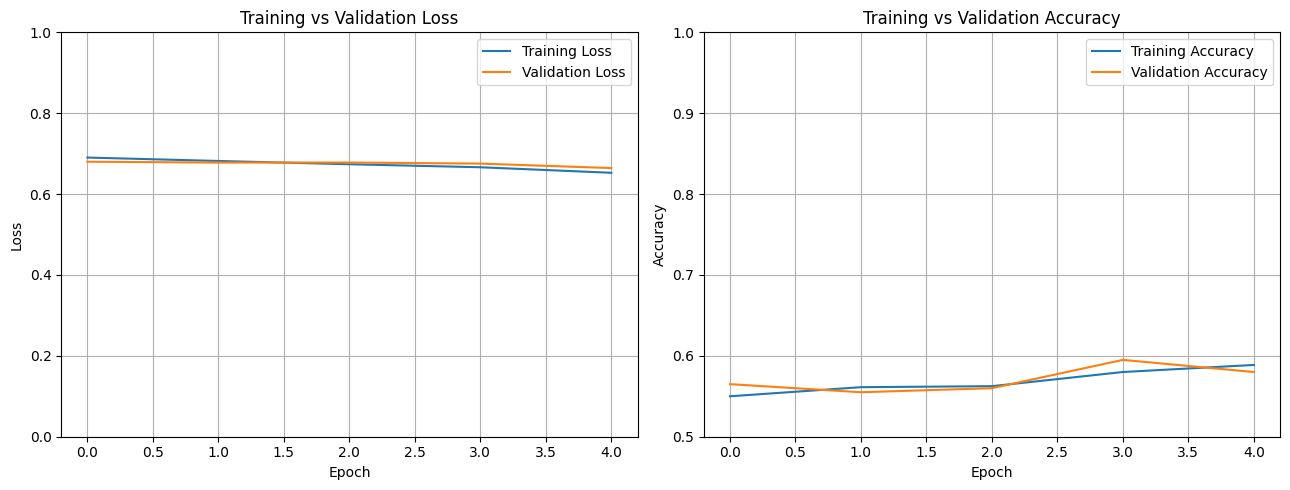

In [ ]:
model = model_lstm_v1(units=16, dropout=0, optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,674,805 (29.28 MB)

 Trainable params: 93,505 (365.25 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.5350 - loss: 0.6892 - val_accuracy: 0.5600 - val_loss: 0.6810
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5763 - loss: 0.6718 - val_accuracy: 0.5450 - val_loss: 0.6782
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6150 - loss: 0.6497 - val_accuracy: 0.5600 - val_loss: 0.6731
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6812 - loss: 0.5960 - val_accuracy: 0.6000 - val_loss: 0.6576
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6837 - loss: 0.5825 - val_accuracy: 0.5750 - val_loss: 0.6865
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Validation F1: 0.7038327526132404 



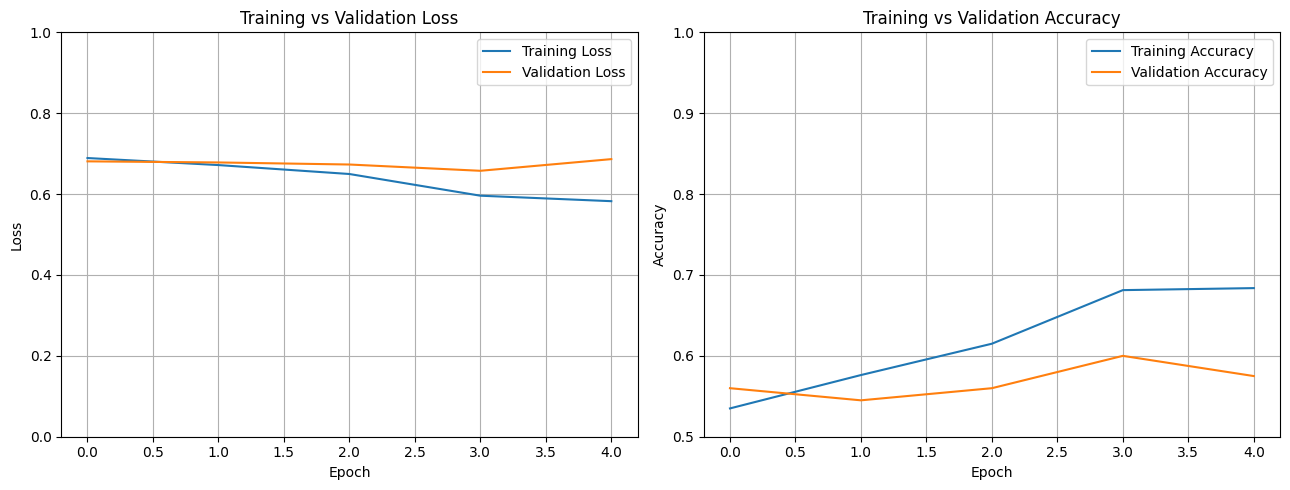

In [ ]:
model = model_lstm_v1(units=64, dropout=0, optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801,077 (29.76 MB)

 Trainable params: 219,777 (858.50 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.5400 - loss: 0.6888 - val_accuracy: 0.5650 - val_loss: 0.6764
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5775 - loss: 0.6581 - val_accuracy: 0.5750 - val_loss: 0.6789
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6450 - loss: 0.6333 - val_accuracy: 0.6200 - val_loss: 0.6616
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7312 - loss: 0.5721 - val_accuracy: 0.6200 - val_loss: 0.8526
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7150 - loss: 0.5728 - val_accuracy: 0.6000 - val_loss: 0.6699


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Validation F1: 0.6116504854368932 



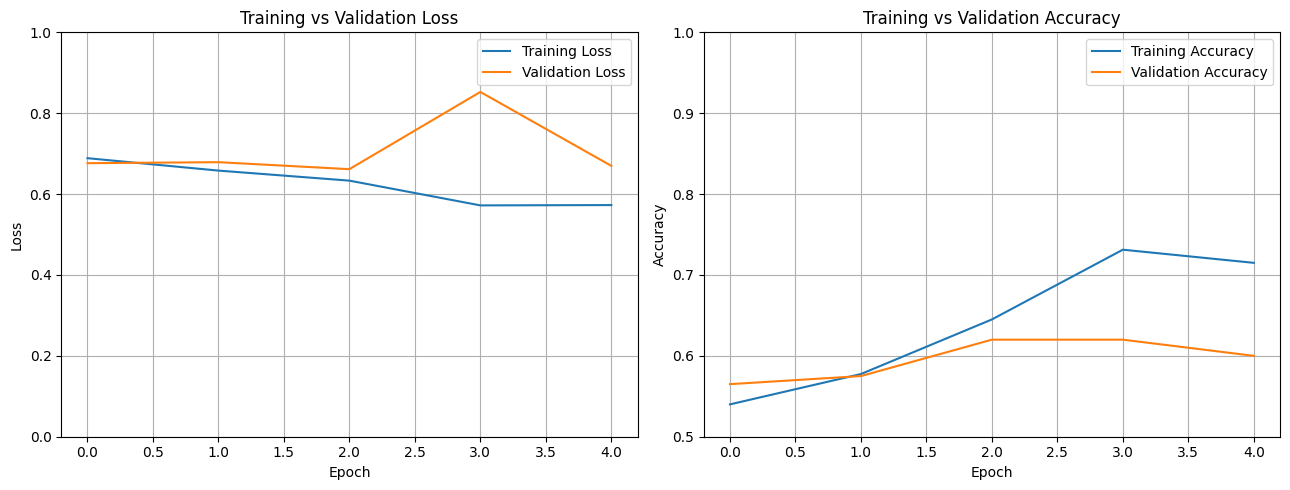

In [ ]:
model = model_lstm_v1(units=128, dropout=0.1, optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

##### Model_LSTM_V2

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 200, 32)        │        42,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,632,277 (29.11 MB)

 Trainable params: 50,977 (199.13 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5350 - loss: 0.6889 - val_accuracy: 0.5600 - val_loss: 0.6836
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5600 - loss: 0.6835 - val_accuracy: 0.5600 - val_loss: 0.6806
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5825 - loss: 0.6729 - val_accuracy: 0.5550 - val_loss: 0.6778
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6087 - loss: 0.6531 - val_accuracy: 0.5750 - val_loss: 0.6746
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6888 - loss: 0.5908 - val_accuracy: 0.5800 - val_loss: 0.6902


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Validation F1: 0.6283185840707964 



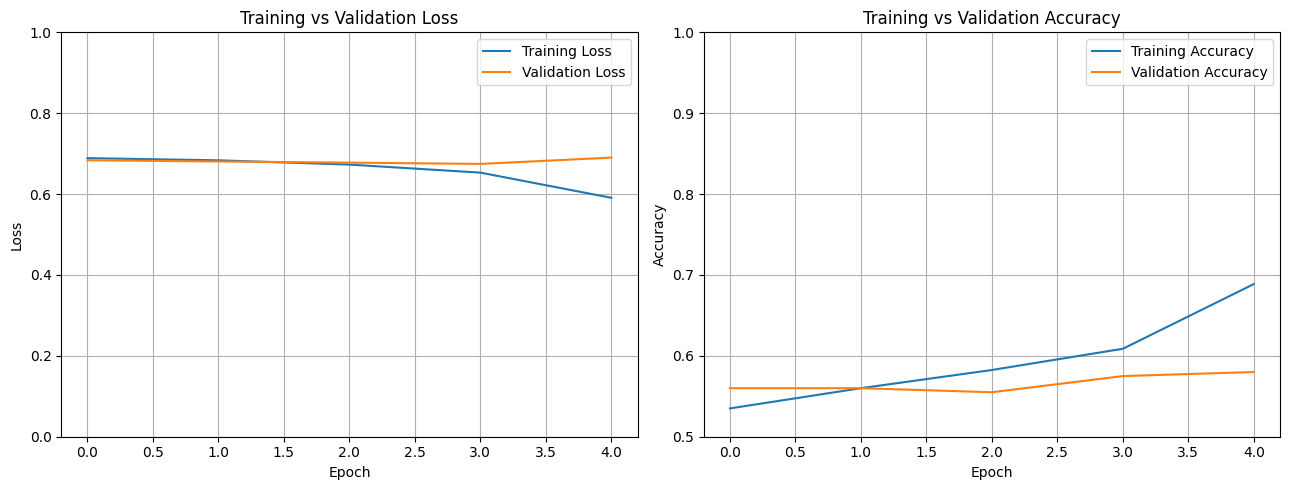

In [ ]:
model = model_lstm_v2(units_1=32, dropout_1=0, units_2=32, dropout_2=0, optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 200, 64)        │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,707,829 (29.40 MB)

 Trainable params: 126,529 (494.25 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5475 - loss: 0.6902 - val_accuracy: 0.5600 - val_loss: 0.6822
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5600 - loss: 0.6795 - val_accuracy: 0.5600 - val_loss: 0.6805
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5725 - loss: 0.6665 - val_accuracy: 0.6000 - val_loss: 0.6761
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6513 - loss: 0.6309 - val_accuracy: 0.5950 - val_loss: 0.6662
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6675 - loss: 0.6018 - val_accuracy: 0.5000 - val_loss: 0.7306
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step

Validation F1: 0.2753623188405797 



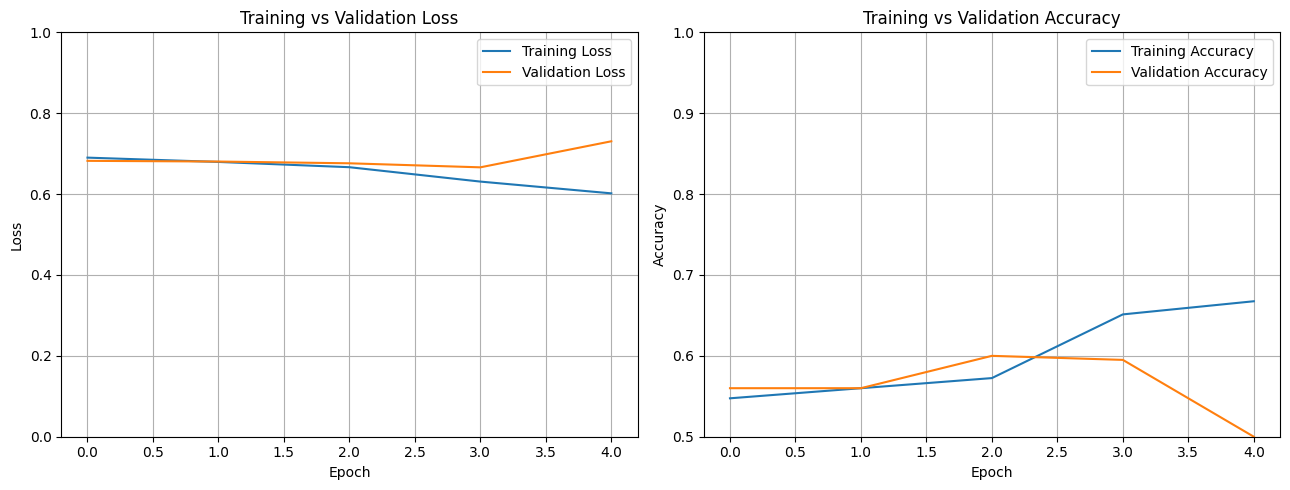

In [ ]:
model = model_lstm_v2(units_1=64, dropout_1=0.1, units_2=64, dropout_2=0.1, optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 200, 128)       │       219,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,932,661 (30.26 MB)

 Trainable params: 351,361 (1.34 MB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5600 - loss: 0.6869 - val_accuracy: 0.5700 - val_loss: 0.6776
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6062 - loss: 0.6473 - val_accuracy: 0.5650 - val_loss: 0.7030
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6850 - loss: 0.5933 - val_accuracy: 0.5600 - val_loss: 0.6979
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6787 - loss: 0.5987 - val_accuracy: 0.5950 - val_loss: 0.6656
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7487 - loss: 0.5404 - val_accuracy: 0.6200 - val_loss: 0.7694
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

Validation F1: 0.5957446808510638 



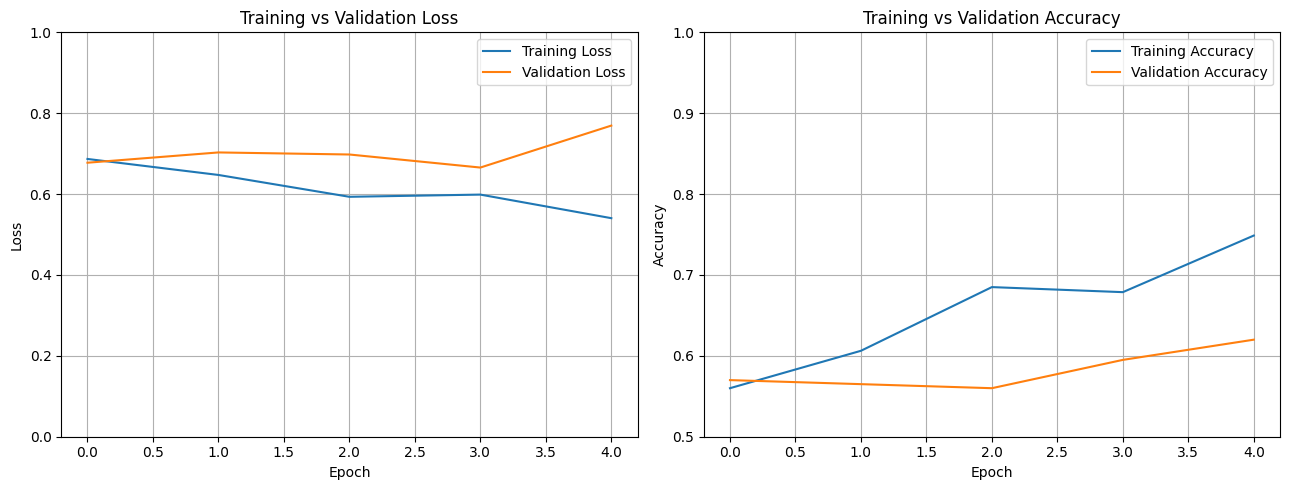

In [ ]:
model = model_lstm_v2(units_1=128, dropout_1=0.1, units_2=128, dropout_2=0.1, optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

##### Model_BRNN_V1

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │        40,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,621,909 (29.08 MB)

 Trainable params: 40,609 (158.63 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5525 - loss: 0.6803 - val_accuracy: 0.5800 - val_loss: 0.6676
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5900 - loss: 0.6556 - val_accuracy: 0.6800 - val_loss: 0.6435
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7038 - loss: 0.6188 - val_accuracy: 0.7400 - val_loss: 0.6088
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7312 - loss: 0.5737 - val_accuracy: 0.6950 - val_loss: 0.5933
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7063 - loss: 0.5550 - val_accuracy: 0.7100 - val_loss: 0.5805
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Validation F1: 0.7456140350877193 



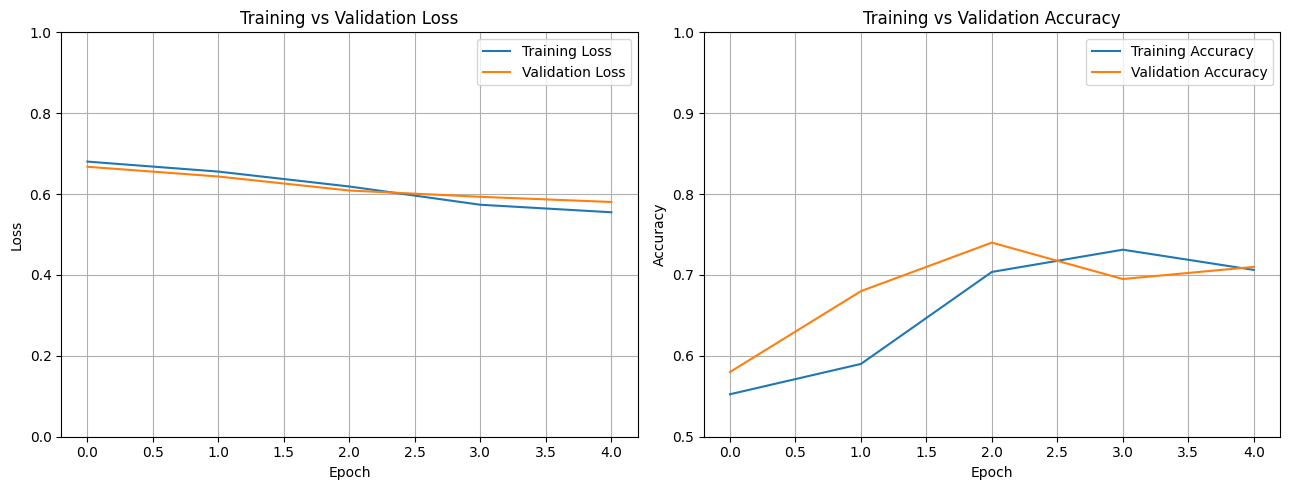

In [ ]:
model = model_brnn_v1(units=16, dropout=0, recurrent_dropout=0, merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,768,309 (29.63 MB)

 Trainable params: 187,009 (730.50 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5775 - loss: 0.6769 - val_accuracy: 0.6800 - val_loss: 0.6462
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6875 - loss: 0.6144 - val_accuracy: 0.6500 - val_loss: 0.6109
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7400 - loss: 0.5407 - val_accuracy: 0.6650 - val_loss: 0.5848
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7437 - loss: 0.5508 - val_accuracy: 0.6900 - val_loss: 0.6209
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7538 - loss: 0.5175 - val_accuracy: 0.7050 - val_loss: 0.5813
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step

Validation F1: 0.7400881057268722 



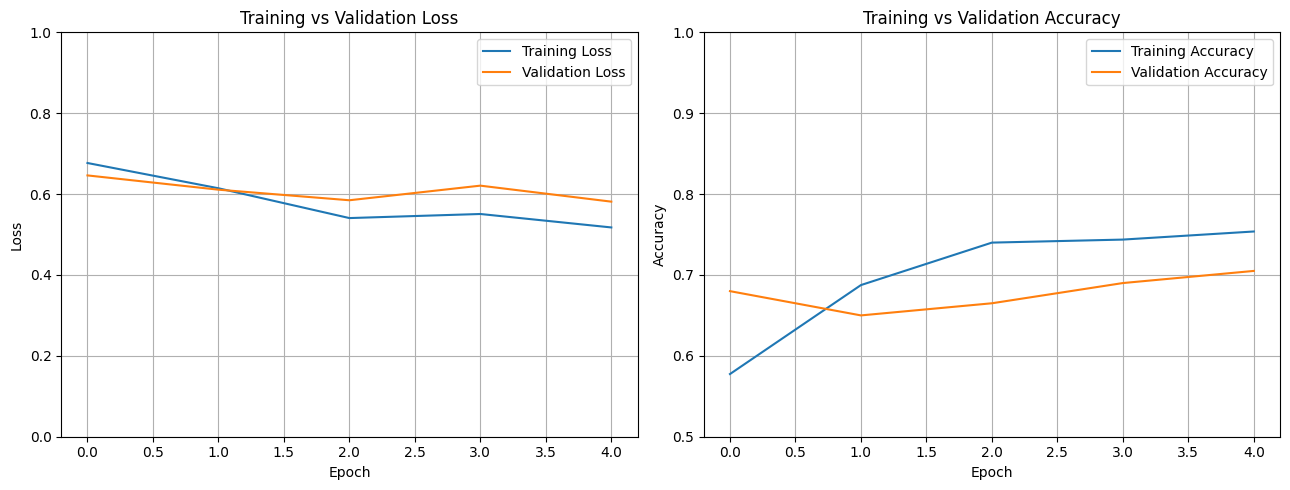

In [ ]:
model = model_brnn_v1(units=64, dropout=0, recurrent_dropout=0, merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,768,309 (29.63 MB)

 Trainable params: 187,009 (730.50 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5487 - loss: 0.6835 - val_accuracy: 0.6050 - val_loss: 0.6581
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 985ms/step - accuracy: 0.6687 - loss: 0.6349 - val_accuracy: 0.7000 - val_loss: 0.6115
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 953ms/step - accuracy: 0.7050 - loss: 0.5776 - val_accuracy: 0.7050 - val_loss: 0.5813
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 963ms/step - accuracy: 0.7538 - loss: 0.5113 - val_accuracy: 0.6900 - val_loss: 0.5800
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 915ms/step - accuracy: 0.7925 - loss: 0.4653 - val_accuracy: 0.7300 - val_loss: 0.5492
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step

Validation F1: 0.7804878048780488 



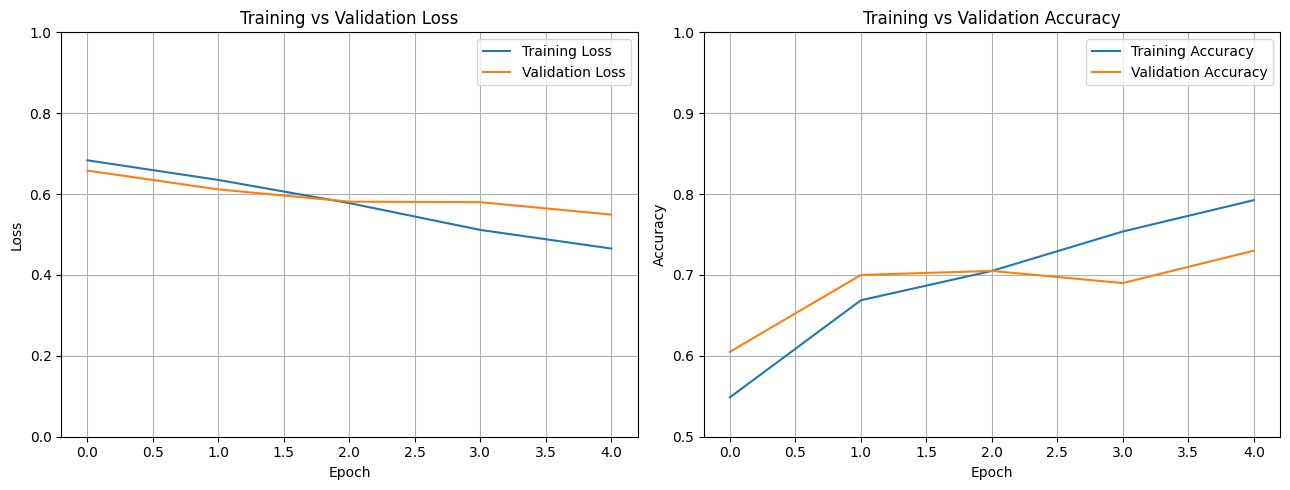

In [ ]:
model = model_brnn_v1(units=64, dropout=0.1, recurrent_dropout=0.1, merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,020,853 (30.60 MB)

 Trainable params: 439,553 (1.68 MB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5825 - loss: 0.6737 - val_accuracy: 0.6850 - val_loss: 0.6316
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6925 - loss: 0.5916 - val_accuracy: 0.5850 - val_loss: 0.6387
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7362 - loss: 0.5444 - val_accuracy: 0.7000 - val_loss: 0.5639
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7513 - loss: 0.5033 - val_accuracy: 0.7000 - val_loss: 0.5674
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7875 - loss: 0.4542 - val_accuracy: 0.7050 - val_loss: 0.5750
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

Validation F1: 0.7377777777777778 



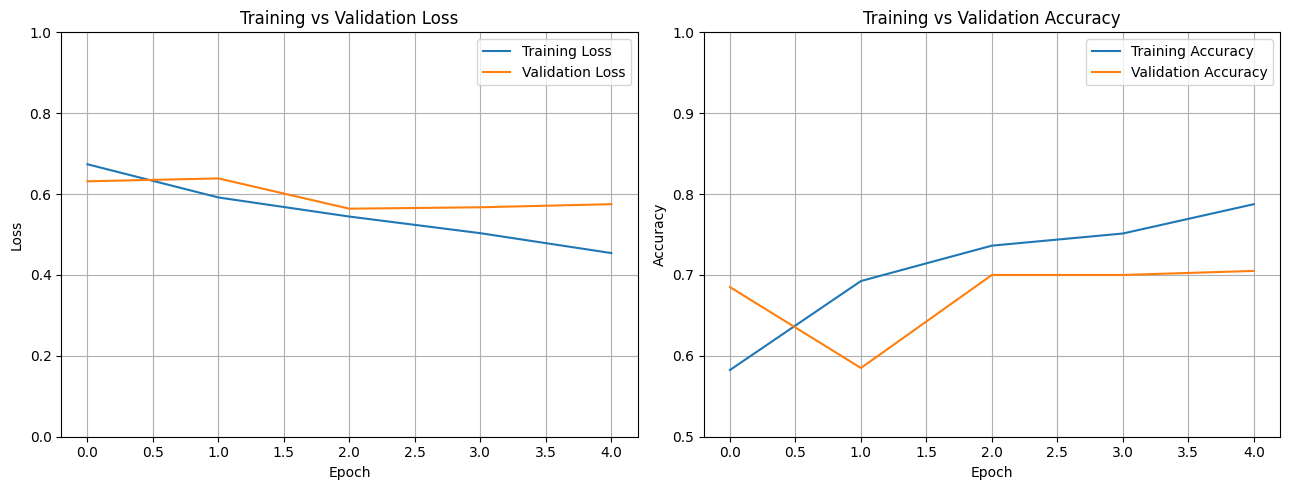

In [ ]:
model = model_brnn_v1(units=128, dropout=0.2, recurrent_dropout=0, merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       439,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,020,853 (30.60 MB)

 Trainable params: 439,553 (1.68 MB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5713 - loss: 0.6767 - val_accuracy: 0.6450 - val_loss: 0.6424
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 992ms/step - accuracy: 0.7138 - loss: 0.5864 - val_accuracy: 0.6650 - val_loss: 0.5962
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7262 - loss: 0.5278 - val_accuracy: 0.6350 - val_loss: 0.5925
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 965ms/step - accuracy: 0.7613 - loss: 0.5264 - val_accuracy: 0.7050 - val_loss: 0.5620
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 993ms/step - accuracy: 0.7575 - loss: 0.4862 - val_accuracy: 0.6850 - val_loss: 0.5882
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 309ms/step

Validation F1: 0.749003984063745 



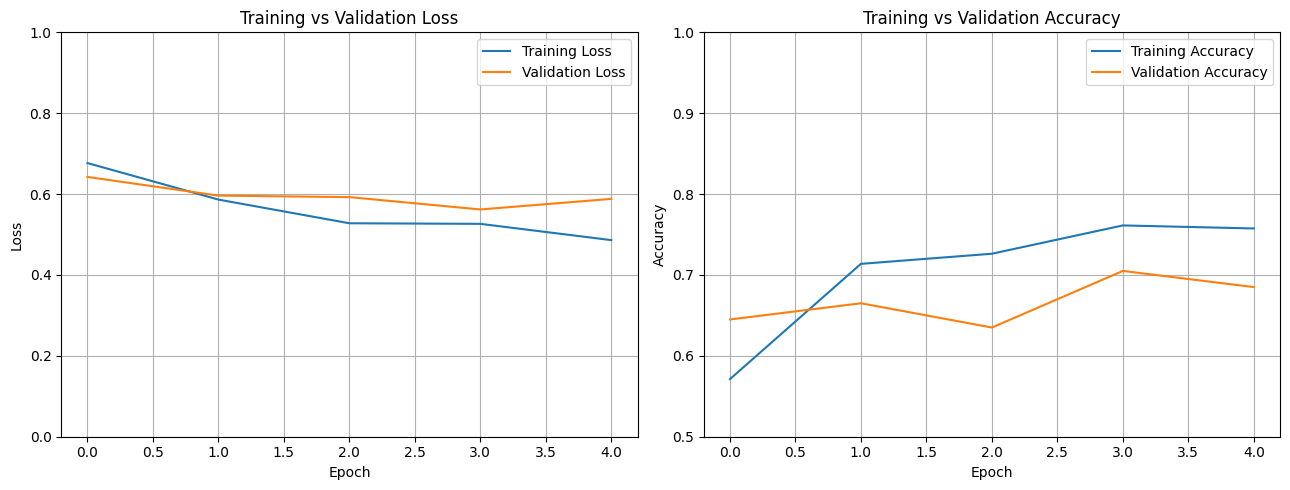

In [ ]:
model = model_brnn_v1(units=128, dropout=0.2, recurrent_dropout=0.05, merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

##### Model_BRNN_V2

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 200, 32)        │        40,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,628,181 (29.10 MB)

 Trainable params: 46,881 (183.13 KB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.5587 - loss: 0.6830 - val_accuracy: 0.5600 - val_loss: 0.6727
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5813 - loss: 0.6624 - val_accuracy: 0.6800 - val_loss: 0.6494
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7175 - loss: 0.6247 - val_accuracy: 0.7250 - val_loss: 0.6104
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7275 - loss: 0.5751 - val_accuracy: 0.6550 - val_loss: 0.6135
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7437 - loss: 0.5348 - val_accuracy: 0.6400 - val_loss: 0.6054
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step

Validation F1: 0.6435643564356436 



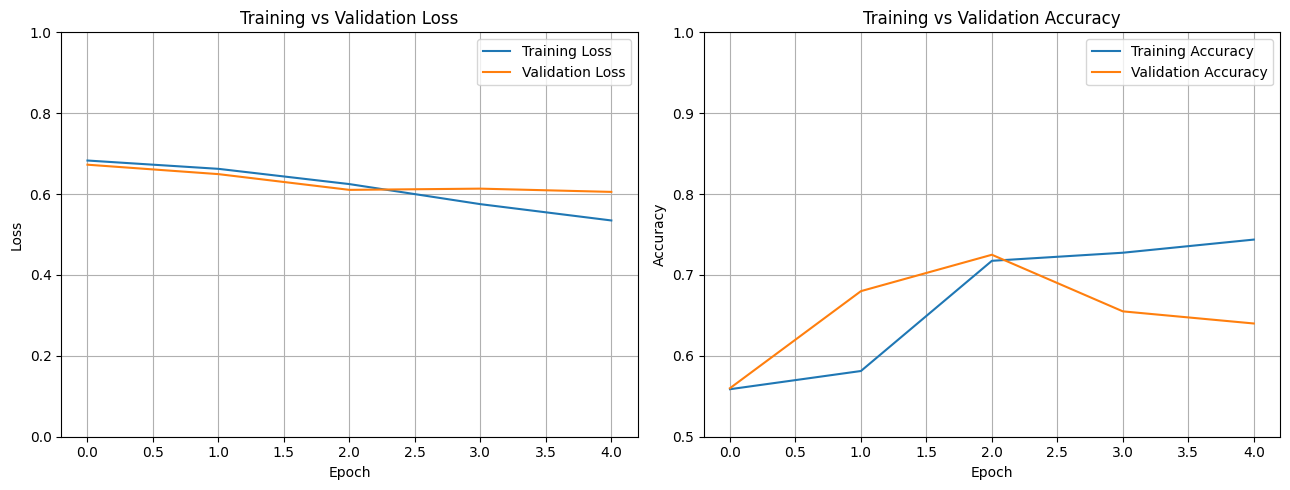

In [ ]:
model = model_brnn_v2(units_1=16, dropout_1=0, recurrent_dropout_1=0, 
                      units_2=16, dropout_2=0, recurrent_dropout_2=0,
                      merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 200, 128)       │       186,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,867,125 (30.01 MB)

 Trainable params: 285,825 (1.09 MB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5675 - loss: 0.6769 - val_accuracy: 0.6850 - val_loss: 0.6399
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7013 - loss: 0.6011 - val_accuracy: 0.7250 - val_loss: 0.5775
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7400 - loss: 0.5122 - val_accuracy: 0.7250 - val_loss: 0.5558
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7763 - loss: 0.4666 - val_accuracy: 0.7000 - val_loss: 0.5849
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.8050 - loss: 0.4268 - val_accuracy: 0.7200 - val_loss: 0.5730
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 603ms/step

Validation F1: 0.7666666666666667 



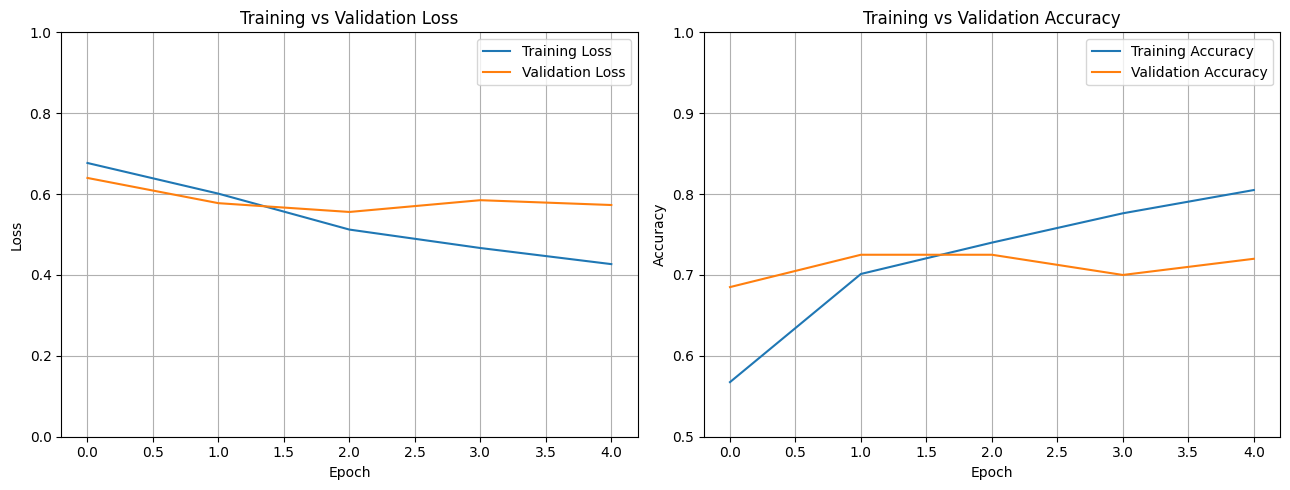

In [ ]:
model = model_brnn_v2(units_1=64, dropout_1=0.1, recurrent_dropout_1=0.1, 
                      units_2=64, dropout_2=0.1, recurrent_dropout_2=0.1,
                      merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 200, 256)       │       439,296 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,415,093 (32.10 MB)

 Trainable params: 833,793 (3.18 MB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.6150 - loss: 0.6738 - val_accuracy: 0.6250 - val_loss: 0.6434
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6700 - loss: 0.5933 - val_accuracy: 0.7250 - val_loss: 0.5610
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7450 - loss: 0.4939 - val_accuracy: 0.6950 - val_loss: 0.5701
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.7800 - loss: 0.4470 - val_accuracy: 0.7300 - val_loss: 0.5613
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8012 - loss: 0.3972 - val_accuracy: 0.6350 - val_loss: 0.6379
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step

Validation F1: 0.6604651162790698 



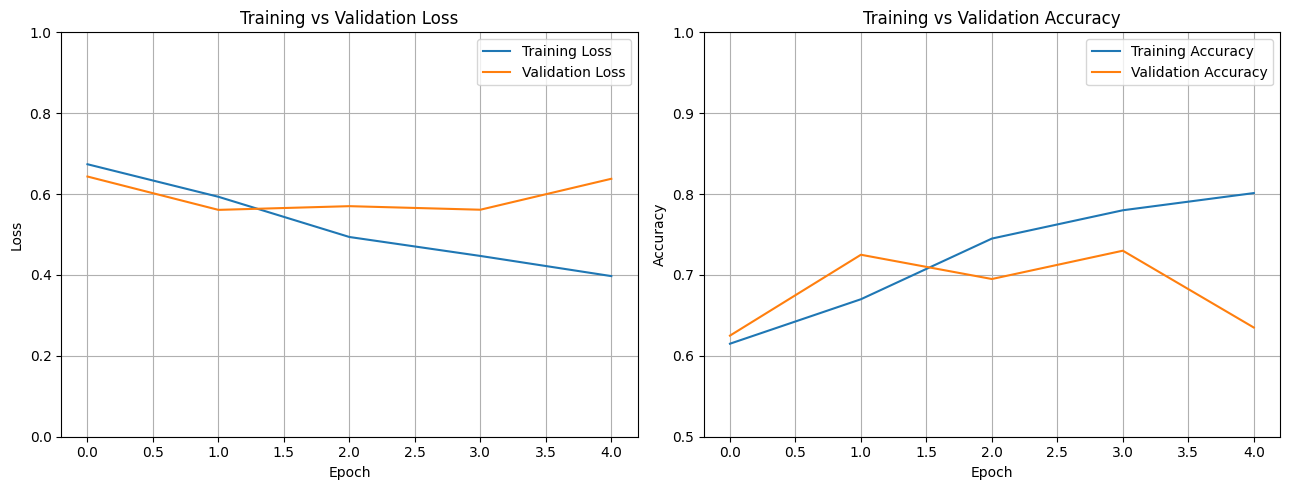

In [ ]:
model = model_brnn_v2(units_1=128, dropout_1=0.3, recurrent_dropout_1=0, 
                      units_2=128, dropout_2=0.3, recurrent_dropout_2=0,
                      merge_mode="concat", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 200, 300)       │     7,581,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 200, 128)       │       439,296 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 128)            │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,283,893 (31.60 MB)

 Trainable params: 702,593 (2.68 MB)

 Non-trainable params: 7,581,300 (28.92 MB)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5813 - loss: 0.6837 - val_accuracy: 0.6800 - val_loss: 0.6402
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6825 - loss: 0.5932 - val_accuracy: 0.7150 - val_loss: 0.5800
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.7312 - loss: 0.5276 - val_accuracy: 0.6800 - val_loss: 0.5629
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7625 - loss: 0.4718 - val_accuracy: 0.6850 - val_loss: 0.5672
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8062 - loss: 0.4039 - val_accuracy: 0.6850 - val_loss: 0.5676
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step

Validation F1: 0.7272727272727273 



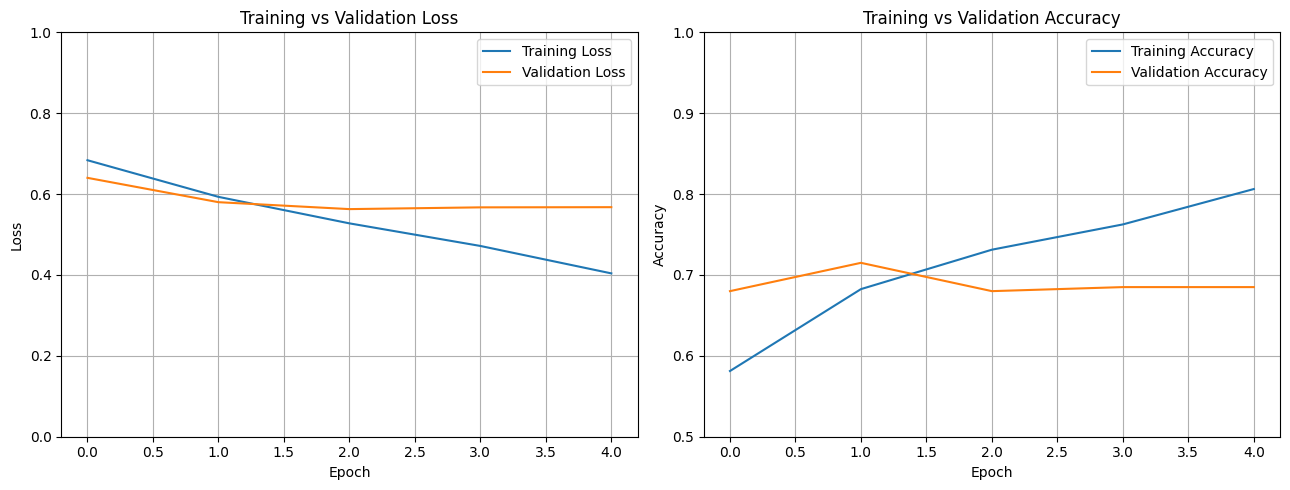

In [ ]:
model = model_brnn_v2(units_1=128, dropout_1=0.3, recurrent_dropout_1=0, 
                      units_2=128, dropout_2=0.3, recurrent_dropout_2=0,
                      merge_mode="sum", optimizer="adam")
model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=5,
    batch_size=64
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

#### BERT

BERT is not performing well as we initially thought. So, again with limitation of time and compute units, we will not use BERT in our real model

In [ ]:
os.environ["KERAS_BACKEND"] = "tensorflow"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 3.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.19.1 which is incompatible.


In [ ]:
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
preprocessor = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en",
    sequence_length=256
)

100%|██████████| 457/457 [00:00<00:00, 948kB/s]


In [ ]:
backbone = keras_hub.models.BertBackbone.from_preset("bert_base_en")

In [ ]:
backbone.trainable = False

# Raw String Input
text_input = keras.Input(shape=(), dtype=str, name="text")
bert_inputs = preprocessor(text_input)
bert_outputs = backbone(bert_inputs)

# For BERT, the pooled CLS-style representation is commonly used for classification
x = bert_outputs["pooled_output"]
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(128, activation="relu")(x)   # new NN layer
x = keras.layers.Dropout(0.2)(x)
output = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(text_input, output)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
    jit_compile=False
)

model.summary()

Model: "functional_43"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_text_classifi… │ [(None, 256),     │          0 │ text[0][0]        │
│ (BertTextClassifie… │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bert_backbone       │ [(None, 768),     │ 108,310,2… │ bert_text_classi… │
│ (BertBackbone)      │ (None, 256, 768)] │            │ bert_text_classi… │
│                     │                   │            │ bert_text_classi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 768)       │          0 │ bert_backbone[10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 128)       │     98,432 │ dropout_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 128)       │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 1)         │        129 │ dropout_30[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,408,833 (413.55 MB)

 Trainable params: 98,561 (385.00 KB)

 Non-trainable params: 108,310,272 (413.17 MB)

In [ ]:
X_raw_train, X_raw_validate, y_raw_train, y_raw_validate = train_test_split(
    df_small["text"], 
    df_small["ai_generated"],
    test_size=0.2,
    random_state=seed,
    stratify=df_small["ai_generated"])

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_raw_train.astype(str).values, y_raw_train.astype("float32").values)
).batch(64)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_raw_validate.astype(str).values, y_raw_validate.astype("float32").values)
).batch(64)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=(
        val_ds
    ),
    epochs=5,
    batch_size=16
)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.5400 - loss: 0.7386 - val_accuracy: 0.5800 - val_loss: 0.6824
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 807ms/step - accuracy: 0.5387 - loss: 0.7297 - val_accuracy: 0.5650 - val_loss: 0.6852
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 806ms/step - accuracy: 0.5275 - loss: 0.7313 - val_accuracy: 0.5800 - val_loss: 0.6747
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 806ms/step - accuracy: 0.5312 - loss: 0.7168 - val_accuracy: 0.5700 - val_loss: 0.6767
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 806ms/step - accuracy: 0.5525 - loss: 0.6988 - val_accuracy: 0.5850 - val_loss: 0.6682


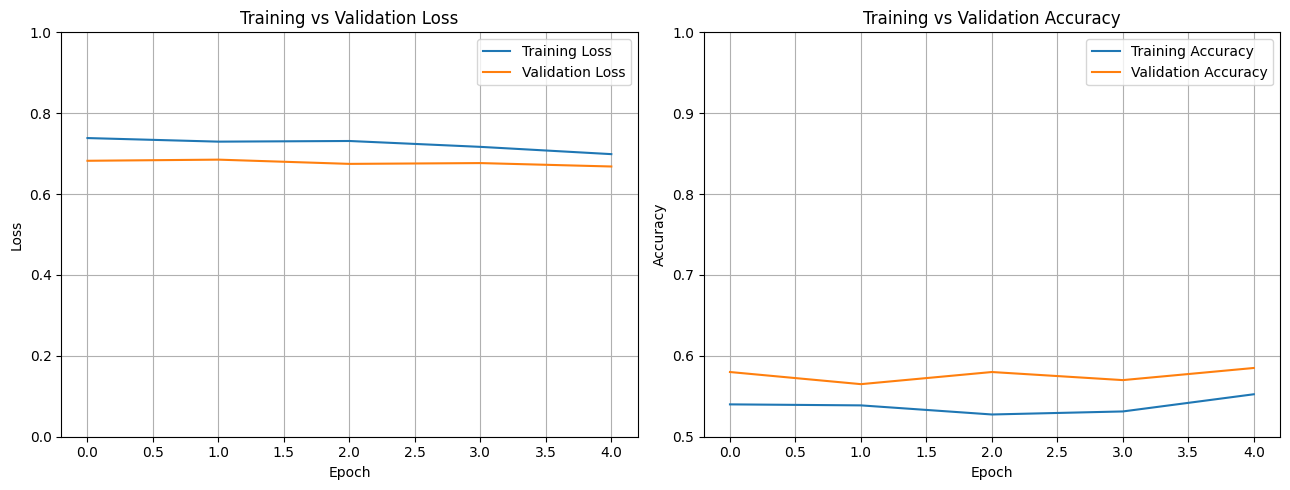

In [ ]:
plot_training_curves(history)

### Training with Bigger Dataset

Now, we increase our training instances from 1000 to 10000 instances and start training our real model. Since we are using the BRNN (v1 and v2) models, we play around with different epochs and tune around the best performing model we tested previously. We choose the one that has solid accuracy, f1-score, and that generalizes well. After testing it out, the two-layer BRNN performs slightly better than the first one. Therefore, for our testing model, we will use the latter one.

In [ ]:
df_real, _ = train_test_split(df, train_size=10000, stratify=df["ai_generated"], random_state=seed)
df_real = df_real.reset_index(drop=True)

print(df_real.shape)
print(df["ai_generated"].value_counts(normalize=True))
print(df_real["ai_generated"].value_counts(normalize=True))

(10000, 2)
ai_generated
1    0.559283
0    0.440717
Name: proportion, dtype: float64
ai_generated
1    0.5593
0    0.4407
Name: proportion, dtype: float64


#### Preprocessing

We will do the same as before.

In [ ]:
texts = df_real["text"].astype(str).tolist()
labels = df_real["ai_generated"].astype(int).values

In [ ]:
file_path = os.path.join(folder_path, "tokenized_texts_train_len-10000_seed-0")

In [ ]:
tokenized_texts = tokenizeTexts(texts, nlp_v1)

In [ ]:
# with open(file_path, "wb") as f:
#     pickle.dump(tokenized_texts, f)

In [ ]:
with open(file_path, "rb") as f:
    tokenized_texts = pickle.load(f)

In [ ]:
word_index = mapWordtoInt(tokenized_texts)
vocab_size = len(word_index)
print("Vocabulary size:", vocab_size)

Vocabulary size: 80187


In [ ]:
sequences = mapWordSeqToIntSeq(tokenized_texts, word_index)
X = pad_sequences(sequences,
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post")
y = labels

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 200)
y shape: (10000,)


In [ ]:
# Do not load this again, if you already load it
# google_w2v = api.load("word2vec-google-news-300")

In [ ]:
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))    # word_id zero for padding

hits = 0
misses = 0

for word, idx in word_index.items():
    if word in google_w2v:
        embedding_matrix[idx] = google_w2v[word]
        hits += 1
    else:
        misses += 1

print("Words found in Google News Word2Vec:", hits)
print("Words not found in Google News Word2Vec:", misses)
print("Embedding matrix shape:", embedding_matrix.shape)

Words found in Google News Word2Vec: 47596
Words not found in Google News Word2Vec: 32591
Embedding matrix shape: (80188, 300)


In [ ]:
X_train, X_validate, y_train, y_validate = train_test_split(
    X, y,
    test_size=0.2,
    random_state=seed,
    stratify=y
)

print(X_train.shape, X_validate.shape)

(8000, 200) (2000, 200)


#### Training

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 200, 300)       │    24,056,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_19                │ (None, 200, 256)       │       439,296 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,890,193 (94.95 MB)

 Trainable params: 833,793 (3.18 MB)

 Non-trainable params: 24,056,400 (91.77 MB)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6554 - loss: 0.6100
Epoch 1: val_loss improved from None to 0.48870, saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v2.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.6902 - loss: 0.5585 - val_accuracy: 0.7200 - val_loss: 0.4887
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7284 - loss: 0.4864
Epoch 2: val_loss improved from 0.48870 to 0.47186, saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v2.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v2.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.7305 - loss: 0.4896 - val_accuracy: 0.7275 - val_loss: 0.4719
Epoch 3/15
125/125 ━━━━

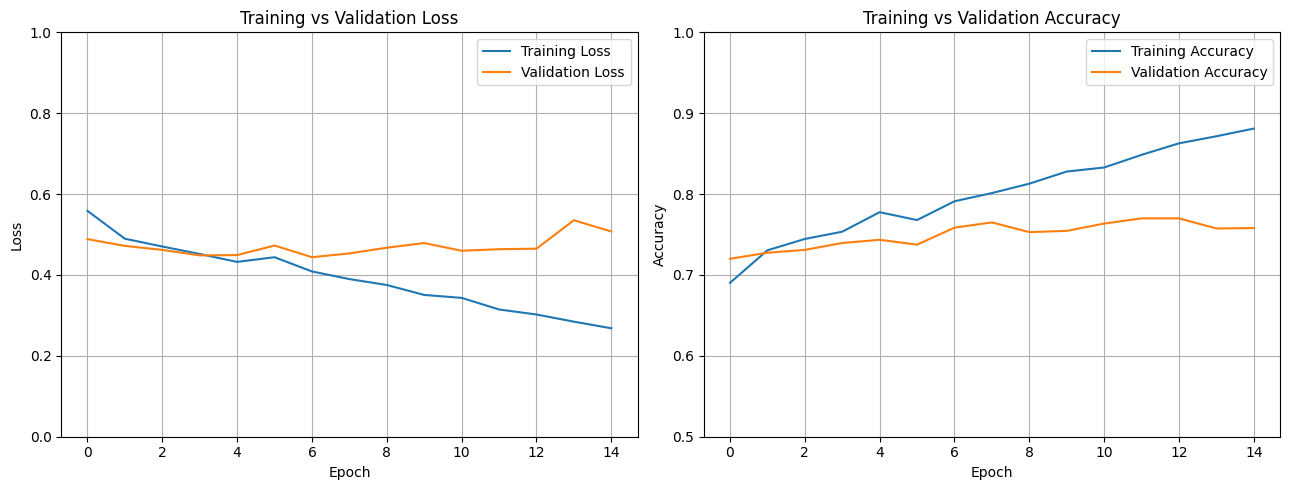

In [ ]:
model = model_brnn_v2(units_1=128, dropout_1=0.3, recurrent_dropout_1=0, 
                      units_2=128, dropout_2=0.3, recurrent_dropout_2=0,
                      merge_mode="concat", optimizer="adam")
model.summary()

best_weight_path = os.path.join(folder_path, "model_brnn_v2.weights.h5")

checkpoint_cb = keras.callbacks.ModelCheckpoint(
        filepath=best_weight_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",               
        verbose=1
        )

history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=15,
    batch_size=64,
    callbacks=[checkpoint_cb]
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_17 (Embedding)        │ (None, 200, 300)       │    24,056,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ (None, 256)            │       439,296 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,495,953 (93.44 MB)

 Trainable params: 439,553 (1.68 MB)

 Non-trainable params: 24,056,400 (91.77 MB)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.6377 - loss: 0.6202
Epoch 1: val_loss improved from None to 0.50129, saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v1.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 77s 580ms/step - accuracy: 0.6809 - loss: 0.5735 - val_accuracy: 0.7230 - val_loss: 0.5013
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.7210 - loss: 0.5050
Epoch 2: val_loss improved from 0.50129 to 0.48678, saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Drexel/INFO371_Drexel/info371_finalProject/model_brnn_v1.weights.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 564ms/step - accuracy: 0.7285 - loss: 0.5001 - val_accuracy: 0.7290 - val_loss: 0.4868
Epoch 3/15
125/12

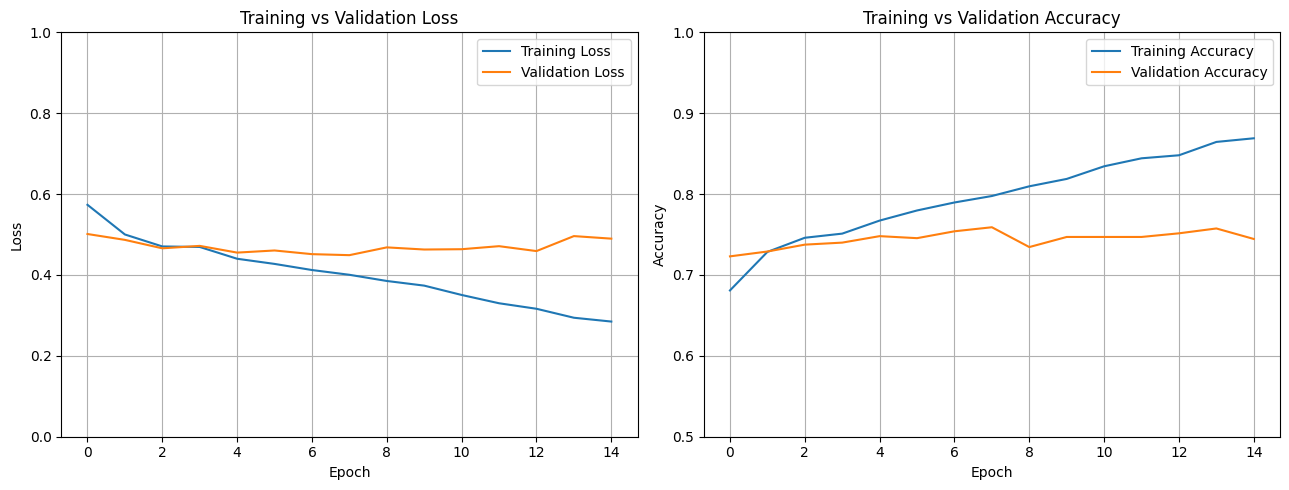

In [ ]:
model = model_brnn_v1(units=128, dropout=0.3, recurrent_dropout=0.2, merge_mode="concat", optimizer="adam")
model.summary()

best_weight_path = os.path.join(folder_path, "model_brnn_v1.weights.h5")

checkpoint_cb = keras.callbacks.ModelCheckpoint(
        filepath=best_weight_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",               
        verbose=1
        )

history = model.fit(
    X_train, y_train,
    validation_data=(X_validate, y_validate),
    epochs=15,
    batch_size=64,
    callbacks=[checkpoint_cb]
)
print("\nValidation F1:", calculate_f1(model, X_validate, y_validate), "\n")
plot_training_curves(history)

### Testing

We sample 10000 instances for testing. We first preprocess our sentences like before, then, load our tokens and models, and check whether our model performs well for test data.

In [ ]:
test = pd.read_csv(os.path.join(folder_path, "test.txt"))

In [ ]:
print(test.info())
print(f"Memory Usage In MB: {test.memory_usage().sum() / 1e6}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157785 entries, 0 to 157784
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   text          157785 non-null  object
 1   text_length   157785 non-null  int64 
 2   word_count    157785 non-null  int64 
 3   ai_generated  157785 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.8+ MB
None
Memory Usage In MB: 5.049252


In [ ]:
df_test = test[["text", "ai_generated"]].copy()
df_test = df_test.dropna(subset=["text", "ai_generated"])

print(df_test.shape)
df_test.head()

(157785, 2)


,text,ai_generated
0,Completing the Doctor of Nursing Practice Proj...,0
1,@ashleycyw \nHi there. I see that you're new ...,0
2,"It's for the University of Texas, what do you ...",0
3,I think this place was pretty good. I'm an eas...,1
4,Every morning a man ran down Phil's street at ...,1


In [ ]:
df_test_small, _ = train_test_split(df_test, train_size=10000, stratify=df_test["ai_generated"], random_state=seed)
df_test_small = df_test_small.reset_index(drop=True)

print(df_test_small.shape)
print(df_test["ai_generated"].value_counts(normalize=True))
print(df_test_small["ai_generated"].value_counts(normalize=True))

(10000, 2)
ai_generated
1    0.55928
0    0.44072
Name: proportion, dtype: float64
ai_generated
1    0.5593
0    0.4407
Name: proportion, dtype: float64


In [ ]:
test_texts = df_test_small["text"].astype(str).tolist()
test_labels = df_test_small["ai_generated"].astype(int).values

Load the training tokens and recalculate the embedding matrix for the model from traning data

In [ ]:
# tokenized_texts = tokenizeTexts(test_texts, nlp_v1)
# with open(file_path, "wb") as f:
#     pickle.dump(tokenized_texts, f)

In [ ]:
# file_path = os.path.join(folder_path, "tokenized_texts_test_len-10000_seed-0")
file_path = os.path.join(folder_path, "tokenized_texts_train_len-10000_seed-0")

In [ ]:
with open(file_path, "rb") as f:
    tokenized_texts = pickle.load(f)

In [ ]:
word_index = mapWordtoInt(tokenized_texts)
vocab_size = len(word_index)
print("Vocabulary size:", vocab_size)

Vocabulary size: 80187


In [ ]:
sequences = mapWordSeqToIntSeq(tokenized_texts, word_index)

In [ ]:
X = pad_sequences(sequences,
    maxlen=MAX_SEQ_LEN,
    padding="post",
    truncating="post")
y = test_labels

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 200)
y shape: (10000,)


In [ ]:
# Do not load this again, if you already load it
# google_w2v = api.load("word2vec-google-news-300")

In [ ]:
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))    # word_id zero for padding

hits = 0
misses = 0

for word, idx in word_index.items():
    if word in google_w2v:
        embedding_matrix[idx] = google_w2v[word]
        hits += 1
    else:
        misses += 1

print("Words found in Google News Word2Vec:", hits)
print("Words not found in Google News Word2Vec:", misses)
print("Embedding matrix shape:", embedding_matrix.shape)

Words found in Google News Word2Vec: 47596
Words not found in Google News Word2Vec: 32591
Embedding matrix shape: (80188, 300)


In [ ]:
model = model_brnn_v2(units_1=128, dropout_1=0.3, recurrent_dropout_1=0, 
                      units_2=128, dropout_2=0.3, recurrent_dropout_2=0,
                      merge_mode="concat", optimizer="adam")
best_weight_path = os.path.join(folder_path, "model_brnn_v2.weights.h5")
model.load_weights(best_weight_path)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
def calculate_metrics(model, X, y_true, threshold=0.5, batch_size=64):
    y_prob = model.predict(X, batch_size=batch_size, verbose=0)
    y_prob = np.array(y_prob).reshape(-1)
    y_true = np.array(y_true).reshape(-1)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

    return metrics

def print_metrics(model, X, y_true, threshold=0.5, batch_size=64):
    metrics = calculate_metrics(model, X, y_true, threshold=threshold, batch_size=batch_size)
    print(f"Accuracy : {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall   : {metrics['recall']:.4f}")
    print(f"F1 Score : {metrics['f1_score']:.4f}")

    return metrics

In [ ]:
metrics = print_metrics(model, X, y)

Accuracy : 0.5091
Precision: 0.5620
Recall   : 0.5543
F1 Score : 0.5581


# 5. Challenges and Limitations
---
- Discuss any challenges encountered during the project, such as:
 * Issues with data quality or availability.
 * Computational or tool constraints.
 * Model-related challenges like overfitting, underfitting, or feature importance.
- Highlight limitations in your analysis or models and how they might affect your conclusions.

## Challenges and Limitations For Deep Learning

Our model performs bad. This is a binary classification problem and if we put all our prediction in the majority class, we will have the accuracy of more than 55%. Our model is worse than that. We believe we know the reason of why that happens:

1. Tokenization Process: We should not lemanize our words in our sequences. The reason we don't want to lemanize is that there exists a lot of information on how humans tend to make mistakes on words. Lemanization takes off that information. The reason we decided to lemanize is that we don't want to explode our words with our limited computing power.
2. Embedding Matrix: Embedding matrix is the most important part of our pipeline. We could think of bigger embedding matrix means better representability of our data. We sampled our training data to include only 10000 instances which is nothing compared to real training data. Therefore, there is a ton of missing words in our embedding matrix. Our pretrained word2vec google model is not good enough to find all the embeddings of our model and we see that with our words' hits and misses. Since, we use 10000 training data to build our embedding matrix, and we have to reuse that embedding matrix for our 10000 test data, we are certain that the words in the traning dataset differs from the original training embedding matrix.
3. Validation Error: In our training data, we have validation accuracy around 76% and f1-score around 78%. This is where we made an error. When we are generating our embedding matrix, we use the data from both traning and validation data but we should have created an embedding matrix from training data and we would see our model not performing well since the beginning.
4. Data: If we look at our losses' and accuracies' plots, we see that our training accuracy is incresing meaning that our model is learning. But validation plot does not increase with the same rate. The sole reason is that we need more data and we can see how nlp are data hungry. We need a lot of data for our model to learn the information about words.
4. Compute and Time Limitations: A lot of our design choices is due to these two constraints. If we were to have good enough compute and time, we can train with larger dataset, bigger embeddings, and tune our hyperparameers more.


# 6. Conclusion and Future Direction
---
- Conclusions: Summarize your main findings in relation to your project objectives.
- Recommendation and Future Direction:
 - Propose actions based on your findings.
 - Suggest next steps for further analysis or research.

# 7. References
---
- List all references for datasets, tools, and external sources used in the project.